In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = {
    'Age': [25, 45, 35, 50, 23, 60, 40, 30, 55, 28,
            48, 32, 65, 38, 22, 58, 42, 27, 52, 34],

    'BloodPressure': [120, 150, 130, 160, 110, 170, 145, 125, 155, 115,
                      150, 128, 175, 135, 108, 165, 140, 118, 158, 132],

    'Cholesterol': [180, 240, 200, 260, 170, 280, 230, 190, 250, 175,
                    245, 195, 290, 210, 165, 270, 225, 185, 255, 205],

    'Sick': [0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
             1, 0, 1, 0, 0, 1, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

df.head()

,Age,BloodPressure,Cholesterol,Sick
0,25,120,180,0
1,45,150,240,1
2,35,130,200,0
3,50,160,260,1
4,23,110,170,0


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            20 non-null     int64
 1   BloodPressure  20 non-null     int64
 2   Cholesterol    20 non-null     int64
 3   Sick           20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None
Age              0
BloodPressure    0
Cholesterol      0
Sick             0
dtype: int64


In [4]:
X = df[['Age', 'BloodPressure', 'Cholesterol']]
y = df['Sick']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [7]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 1 1]


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



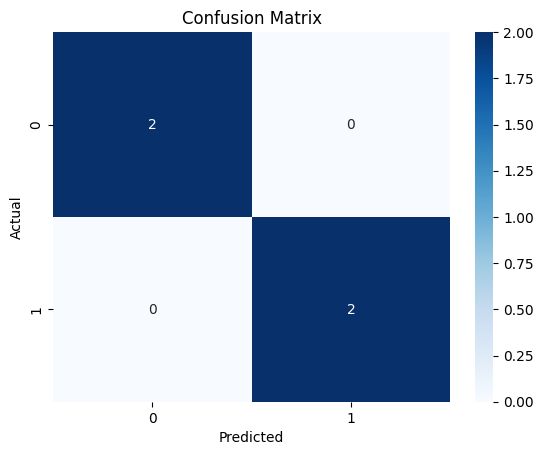

In [11]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [12]:
new_patient = [[45, 150, 240]]

prediction = model.predict(new_patient)

if prediction[0] == 1:
    print("Prediction: Sick")
else:
    print("Prediction: Healthy")

Prediction: Sick


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


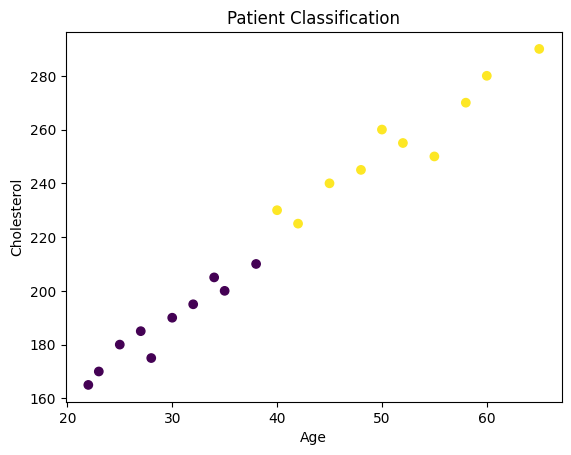

In [13]:
plt.scatter(df['Age'], df['Cholesterol'], c=df['Sick'])

plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Patient Classification')
plt.show()